# Домашенее задание №8 Случайный лес

**Цель задания** — обучить случайный лес на уже известном и предобработанном вами датасете из 4 домашки (или на любом другом датасете)

**Задача** — дополнить ноутбук из домашнего задания 4 про линейную регрессию (или написать новый, если задание 4 вы не сделали xD). В ходе работы вы должны дать развернутые ответы на ряд ключевых вопросов (см. ниже).

**Columns:**

* Id: Уникальный идентификатор для каждой записи об автомобиле.

* Model: Название модели Toyota Corolla.

* Price: Цена продажи подержанного автомобиля.

* Age_08_04: Возраст автомобиля в месяцах по состоянию на август 2004 года.

* Mfg_Month: Месяц производства автомобиля.

* Mfg_Year: Год производства автомобиля.

* KM: Количество километров, пройденных автомобилем.

* Fuel_type: Тип топлива, используемого автомобилем (например, бензин, дизельное топливо).

* HP: Лошадиные силы, показатель мощности двигателя.

* Met_Color: Двоичный индикатор для металлизированной краски (0 = Нет, 1 = Да).

* Color: Цвет кузова автомобиля.
Automatic: Двоичный индикатор для автоматической коробки передач (0 = Нет, 1 = Да).

* CC: Объем двигателя в кубических сантиметрах.

* Doors: Количество дверей автомобиля.
* Cylinders: Количество цилиндров в двигателе.

* Gears: Количество передач в трансмиссии.
Quarterly: Квартальный налог на автомобиль.

* Weight: Вес автомобиля.

* Mfr_Guarantee: Двоичный индикатор гарантии производителя (0 = Нет, 1 = Да).

* BOVAG_Guarantee: Двоичный индикатор гарантии BOVAG (0 = Нет, 1 = Да).

* Guarantee_Period: Срок гарантии в месяцах.

* ABS: Двоичный индикатор антиблокировочной системы тормозов (0 = Нет, 1 = Да).

* Airbag_1: Двоичный индикатор наличия подушки безопасности 1 (0 = Нет, 1 = Да).

* Airbag_2: Двоичный индикатор наличия подушки безопасности 2 (0 = Нет, 1 = Да).

* Airco: Двоичный индикатор кондиционера (0 = Нет, 1 = Да).

* Automatic_airco: Двоичный индикатор автоматического кондиционирования воздуха (0 = Нет, 1 = Да).

In [1]:
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, PolynomialFeatures,StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.datasets import make_classification
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from scipy.stats import kstest, norm

In [2]:
path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")

fiels=os.listdir(path)

csv_file=[f for f in fiels if f.endswith('.csv')][0]
full_f_path=os.path.join(path,csv_file)

# Настройка отображения
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

print("1. Загрузка данных...")
df = pd.read_csv(full_f_path)

Using Colab cache for faster access to the 'price-of-used-toyota-corolla-cars' dataset.
1. Загрузка данных...


## 1. Разделение выборки

Подготовьте данные для обучения модели.

**Обязательно объясните текстом:**
* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?**
* **Как именно вы разделили выборку?**
* **На сколько частей нужно делить выборку при использовании кросс-валидации?**
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?**

In [3]:
df.head(3)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0


In [4]:
print('\nКолличество записей:',df.count())
print('\nИнформация:',df.info())


Колличество записей: Id                   1436
Model                1436
Price                1436
Age_08_04            1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistan

In [5]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,4.0,5.026462,87.122563,1072.45961,0.409471,0.895543,3.815460,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,0.218663,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,0.0,0.188510,41.128611,52.64112,0.491907,0.305959,3.011025,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,0.413483,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,4.0,3.000000,19.000000,1000.00000,0.000000,0.000000,3.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,4.0,5.000000,69.000000,1040.00000,0.000000,1.000000,3.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,4.0,5.000000,85.000000,1070.00000,0.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,4.0,5.000000,85.000000,1085.00000,1.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,4.0,6.000000,283.000000,1615.00000,1.000000,1.000000,36.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
print('\nПропуски:\n',df.isnull().sum())


Пропуски:
 Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


In [7]:
df.drop_duplicates()
df.dropna()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,Blue,0,1300,3,4,5,69,1025,1,1,3,1,1,1,1,0,0,0,1,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,Grey,0,1300,3,4,5,69,1015,0,1,3,1,1,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,Blue,0,1300,3,4,5,69,1015,0,1,3,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,Grey,0,1300,3,4,5,69,1015,1,1,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [8]:
miss_val=df.isnull().sum()

col_miss_val=miss_val[miss_val>0]

if col_miss_val.empty:
  print("Пропусков нет в датафрейме")
else:
  print(col_miss_val)

if not col_miss_val.empty:
  for col in col_miss_val.index:
    if df[col].dtype in ['int64','float64']:
      df[col]=df[col].fillna(df[col].median())
    if df[col].dtype == 'object':
      df[col]=df[col].fillna(df[col].mode())
else:
  print("\nВ датафрейме нет пропущенных значений, поэтому заполнение не требуется.")

Пропусков нет в датафрейме

В датафрейме нет пропущенных значений, поэтому заполнение не требуется.


In [9]:
categorical_cols=df.select_dtypes(include=['object']).columns

if not categorical_cols.empty:
  print("Распределение классов для категориальных столбцов:")
  for col in categorical_cols:
    display(df[col].value_counts())
    print("\n")
else:
    print("В датафрейме нет категориальных столбцов для анализа классов.")

Распределение классов для категориальных столбцов:


,count
Model,
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors,109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors,80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors,71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors,54
...,...
TOYOTA Corolla 1.8 VVTL-i T-Sport 3-Drs 2/3-Doors,1
TOYOTA Corolla 2.0 D4D 90 5DR TERRA 4/5-Doors,1
TOYOTA Corolla 1800 T SPORT VVT I 2/3-Doors,1


,count
Fuel_Type,
Petrol,1264
Diesel,155
CNG,17


,count
Color,
Grey,301
Blue,283
Red,278
Green,220
Black,191
Silver,122
White,31
Violet,4
Yellow,3


<Axes: >

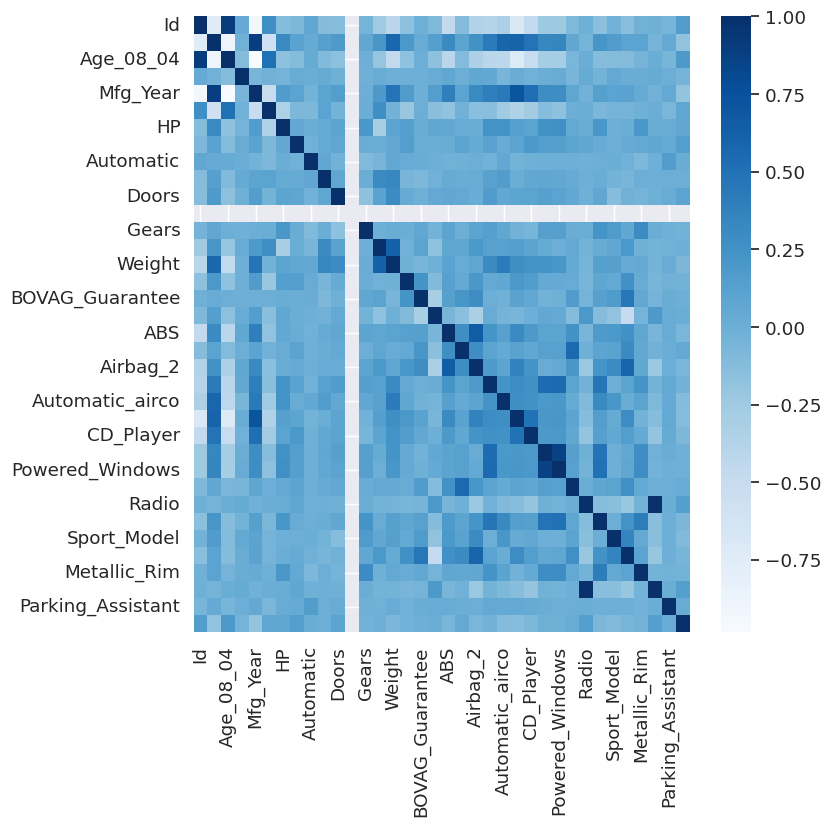

In [10]:
corss=df.corr(numeric_only=True)

fig,ax=plt.subplots(figsize=(8,8))
sns.heatmap(corss,cmap='Blues',annot=False,fmt=".2f")

In [11]:
#Удаления признаков с нулевой дисперсией
variancy=df.var(numeric_only=True, ddof=0)
col=variancy[variancy == 0].index
df = df.drop(columns=col)


In [12]:
df.head(2)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0


In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)
X=df_encoded.drop('Price',axis=1)
y=df_encoded['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

cat_col=X.select_dtypes(include='object').columns
print('Train shape:',X_train.shape)
print('Test shape:',X_test.shape)


Train shape: (1148, 363)
Test shape: (288, 363)


In [14]:
df_encoded.head()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Model_TOYOTA Corolla ! 1.6-16v vvt-i sol airco sedan 4/5-Doors,Model_TOYOTA Corolla 1 6-16v VVT-i Linea Terra Comfort Airco 5drs 4/5-Doors,Model_TOYOTA Corolla 1.3 16V 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB LINEA LUNA 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB LINEA LUNA AUT3 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA AUT3 2/3-Doors,Model_TOYOTA Corolla 1.3 16V HATCHB S 2/3-Doors,Model_TOYOTA Corolla 1.3 16V L. TERRA COMFORT 2/3-Doors,Model_TOYOTA Corolla 1.3 16V LB Linea Luna 4/5-Doors,Model_TOYOTA Corolla 1.3 16V LIFTB G6 4/5-Doors,Model_TOYOTA Corolla 1.3 16V LIFTB LINEA LUNA 4/5-Doors,Model_TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA 4/5-Doors,Model_TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA AUT3 4/5-Doors,Model_TOYOTA Corolla 1.3 16V Linea Terra 2/3-Doors,Model_TOYOTA Corolla 1.3 16V Linea Terra 4/5-Doors,Model_TOYOTA Corolla 1.3 16V Linea Terra Liftb 2/3-Doors,Model_TOYOTA Corolla 1.3 16V Linea Terra Liftb 4/5-Doors,Model_TOYOTA Corolla 1.3 16V SEDAN LINEA TERRA 4/5-Doors,Model_TOYOTA Corolla 1.3 16V SEDAN LINEA TERRA AUT3 4/5-Doors,Model_TOYOTA Corolla 1.3 16V WAGON LINEA LUNA Stationwagen,Model_TOYOTA Corolla 1.3 16V WAGON LINEA TERRA Stationwagen,Model_TOYOTA Corolla 1.3 16v linea terra,Model_TOYOTA Corolla 1.3 3D Linea Terra 2/3-Doors,Model_TOYOTA Corolla 1.3 G6 liftback 4/5-Doors,Model_TOYOTA Corolla 1.3 HB LINEA TERRA 2/3-Doors,Model_TOYOTA Corolla 1.3 HB LINEA TERRA AUT 2/3-Doors,Model_TOYOTA Corolla 1.3 HB LINEA TERRA AUT Anders,Model_TOYOTA Corolla 1.3 HB Linea Terra 2/3-Doors,Model_TOYOTA Corolla 1.3 Hatchback 2/3-Doors,Model_TOYOTA Corolla 1.3 I LUNA 2/3-Doors,Model_TOYOTA Corolla 1.3 LB LINEA TERRA 4/5-Doors,Model_TOYOTA Corolla 1.3 LIN. Terra 2/3-Doors,Model_TOYOTA Corolla 1.3 Linea Luna Hatchback 2/3-Doors,Model_TOYOTA Corolla 1.3 Linea Terra 3 drs 2/3-Doors,Model_TOYOTA Corolla 1.3 Linea Terra 4/5-Doors,Model_TOYOTA Corolla 1.3 Linea Terra Comfort 4/5-Doors,Model_TOYOTA Corolla 1.3 Linea Terra Hatchback 2/3-Doors,Model_TOYOTA Corolla 1.3 Linea Terra liftback 4/5-Doors,Model_TOYOTA Corolla 1.3 Linea Terra sedan 4/5-Doors,Model_TOYOTA Corolla 1.3 Linea Terra sedan Comf. 4/5-Doors,Model_TOYOTA Corolla 1.3 Linea Terra wagon Stationwagen,Model_TOYOTA Corolla 1.3 SDN LINEA TERRA AUT 4/5-Doors,Model_TOYOTA Corolla 1.3-16V Luna 2/3-Doors,Model_TOYOTA Corolla 1.3I LINEATERRA 2/3-Doors,Model_TOYOTA Corolla 1.3i LINEA TERRA 2/3-Doors,Model_TOYOTA Corolla 1.3i-16v Linea Terra 5d 4/5-Doors,Model_TOYOTA Corolla 1.4 16V 5DR TERRA 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 3DR 2/3-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 3DR TERRA 2/3-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 3DR TERRA COMFORT 2/3-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR LUNA 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR LUNA BNS 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR SOL 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR TERRA 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I 5DR TERRA COMFORT 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I HATCHB SOL 2/3-Doors,Model_TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors,Model_TOYOTA Corolla 1.4 16V VVT I LIFTB LUNA 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I LIFTB SOL 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I LIFTB TERRA 4/5-Doors,Model_TOYOTA Corolla 1.4 16V VVT I SEDAN TERRA COMF 4/5-Doors,Model_TOYOTA Corolla 1.4 HB LINEA TERRA 2/3-Doors,Model_TOYOTA Corolla 1.4 HB Terra 2/3-Doors,Model_TOYOTA Corolla 1.4 LB LINEA TERRA 4

**Обязательно объясните текстом:**
* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?**

Да.Для случайного леса не обязательны маштабирование и нормализация,как для линейной регрессии. Так же при обработке данных я удалила признаки у который дисперсия равна 0. Так как ключевым дествием модели будет снижение дисперсии.

* **Как именно вы разделили выборку?**

Разделила на 80 на train и 20 на test

* **На сколько частей нужно делить выборку при использовании кросс-валидации?**

На 5 частей, так как датафрейм не очень большой

* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?**

Да можно. Основным деление, будет деление выборки на train и test. При отсутствии cv результат зависит от случайного разбиения.

## 2. Обучение моделей

Обучите случайный лес. Обучите одно дерево той же глубины, какую вы укажете в случайном лесе. Сравните результаты.

**Вопросы для анализа:**
* **Сравнение скорости:** сравните, какая модель обучалась быстрее.
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?**
* **Сравнение качества:** сравните результаты одного дерева и случайного леса.


In [15]:
t0_1=time.time()

In [16]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

rf_depth = rf.estimators_[0].get_depth()  # Глубина первого дерева
print(f"Глубина деревьев в Random Forest: {rf_depth}")

depths=[i_tree.get_depth() for i_tree in rf.estimators_]
same= np.mean(depths)

rf_time=time.time()-t0_1

print(f"Средняя глубина: {round(same)}")
print(f"Min глубина: {min(depths)}")
print(f"Max глубина: {max(depths)}")
print(f"Время выполнения: {rf_time}")

Глубина деревьев в Random Forest: 22
Средняя глубина: 23
Min глубина: 20
Max глубина: 33
Время выполнения: 3.6015822887420654


In [17]:
t0_2=time.time()

In [18]:
tree=DecisionTreeRegressor(max_depth=round(same),criterion='squared_error',random_state=42)
tree.fit(X_train,y_train)

tr_time=time.time()-t0_2

print(f"Время выполнения: {tr_time}")
print(f"Глубина дерева: {tree.get_depth()}")

Время выполнения: 0.06523752212524414
Глубина дерева: 23


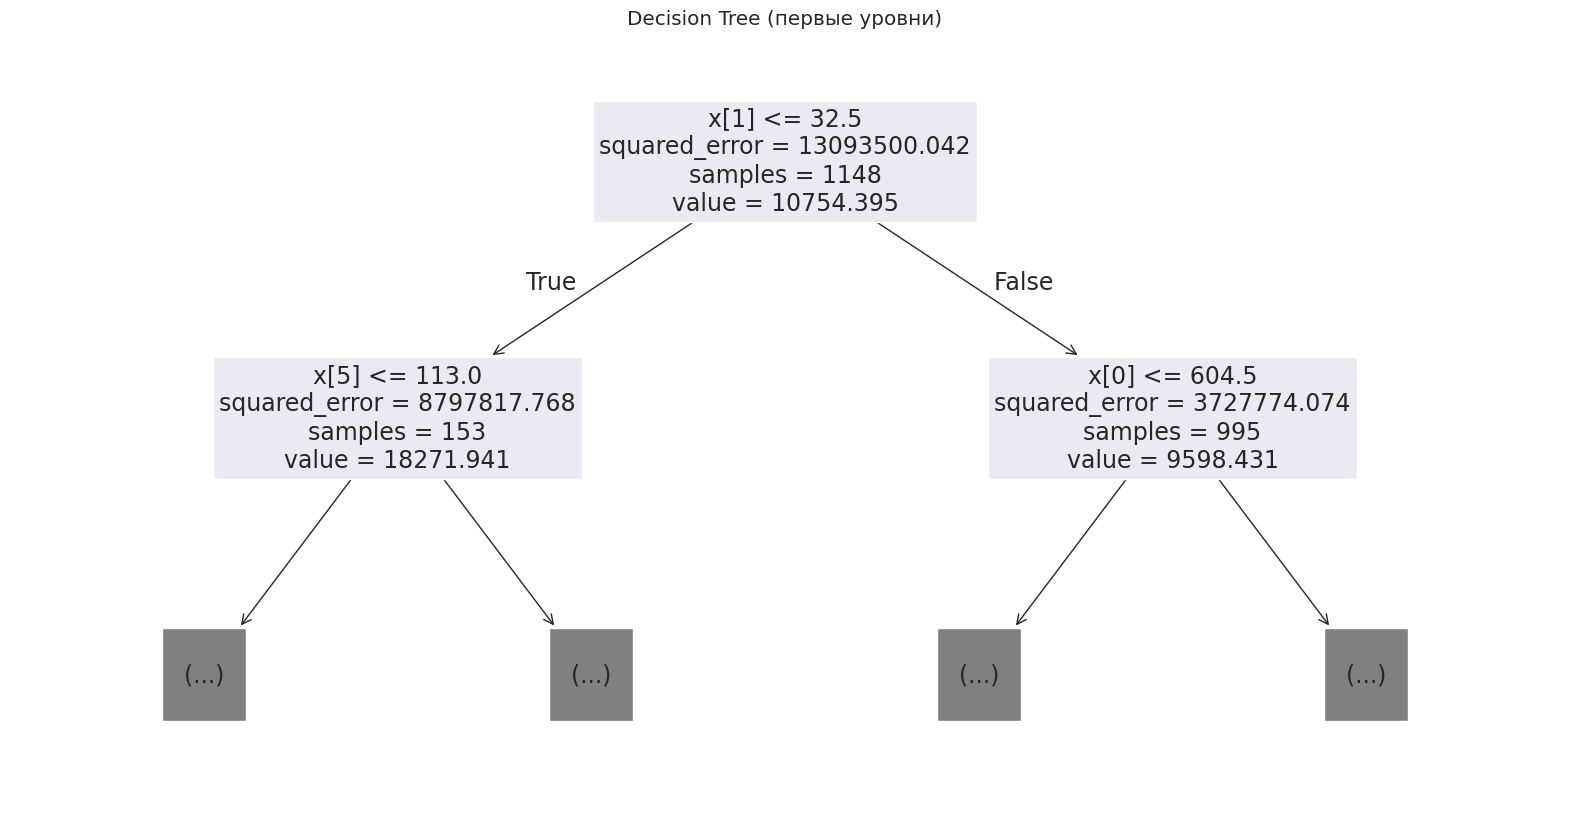

In [19]:
plt.figure(figsize=(20, 10))
plot_tree(tree,max_depth=1)
plt.title("Decision Tree (первые уровни)")
plt.show()

In [20]:
def get_metrics(y_true,y_pred):
  return {
      'r2 ': r2_score(y_true,y_pred),
      'MSE': mean_squared_error(y_true,y_pred),
      'MAE': mean_absolute_error(y_true,y_pred),
      'RMSE': np.sqrt(mean_squared_error(y_true,y_pred)),
  }

In [21]:
y_pred_rf = rf.predict(X_test)
y_pred_tree = tree.predict(X_test)

res = pd.DataFrame([
    get_metrics(y_test,y_pred_rf),
    get_metrics(y_test,y_pred_tree),

],index=['RandomForest','Tree'])

display(res.round(2))
cv_rf = cross_val_score(estimator = rf, X = X_train, y = y_train, cv=5)
cv_tree = cross_val_score(estimator = tree, X = X_train, y = y_train, cv=5)
print('\nВремя выполнения RandomForest :',rf_time)
print('\nВремя выполнения DesicionTree :',tr_time)
display(cv_rf)
display(cv_tree)

,r2,MSE,MAE,RMSE
RandomForest,0.93,947006.48,744.34,973.14
Tree,0.86,1879165.52,1024.80,1370.83



Время выполнения RandomForest : 3.6015822887420654

Время выполнения DesicionTree : 0.06523752212524414


array([0.90147942, 0.90975683, 0.91423663, 0.92944077, 0.8818775 ])

array([0.86175373, 0.8230717 , 0.82499403, 0.86634455, 0.79397268])

**Сравнение скорости:** сравните, какая модель обучалась быстрее.

Дерево решений

**Можно ли добиться одинаковой или близкой к одинаковой скорости?**

Нет, нельзя потому что всегда будет разница в колличестве обробатываемых деревьев

**Сравнение качества:** сравните результаты одного дерева и случайного леса.

Качественнее результаты RandomForest

## Линейная регрессия

In [22]:
#Чистим от ненужных признаков
train_df=X_train.copy()
train_df['Price']=y_train

corr_matrix=train_df.corr(numeric_only=True)
target_corr=corr_matrix['Price'].abs()

treshold = 0.05 # можно менять на больший выброс
low_corr_cols = target_corr[target_corr <= treshold].index.tolist()


#Убираем сам таргет Price

low_corr_cols=[col for col in low_corr_cols if col != 'Price']

cols_to_drop = list(set(low_corr_cols + ['Cylinders']))# не нужен одни значения Nan

print(f"Признаки с корреляцией < {treshold} по модулю: {cols_to_drop}")

print(f"Удаляем признаки: {cols_to_drop}")

X_train_e1 = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test_e1 = X_test.drop(columns=cols_to_drop, errors='ignore')

print("TRAIN columns:", X_train_e1.columns)
print("TEST columns:", X_test_e1.columns)

Признаки с корреляцией < 0.05 по модулю: ['Model_TOYOTA Corolla 1.6 GTSi HB 4/5-Doors', 'Model_TOYOTA Corolla 1.6 16v Linea Luna Stationwagen', 'Model_TOYOTA Corolla 1.3 16V WAGON LINEA TERRA Stationwagen', 'Model_TOYOTA Corolla 1.4 16V VVT I SEDAN TERRA COMF 4/5-Doors', 'Model_TOYOTA Corolla 1.3 Linea Terra 4/5-Doors', 'Model_TOYOTA Corolla 1.6 HB LINEA LUNA 2/3-Doors', 'Model_TOYOTA Corolla 1.6 Terra HB 2/3-Doors', 'Model_TOYOTA Corolla LIFTBACK 1.6 Linea terra 4/5-Doors', 'Model_TOYOTA Corolla 1.6 HATCHBACK 2/3-Doors', 'Model_TOYOTA Corolla 1 6-16v VVT-i Linea Terra Comfort Airco 5drs 4/5-Doors', 'Model_TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA AUT4 4/5-Doors', 'Model_TOYOTA Corolla 1.3 16V LIFTB G6 4/5-Doors', 'Model_TOYOTA Corolla 1.6 VVTi Linea Luna 4/5-Doors', 'Model_TOYOTA Corolla 1.6 16V G6 2/3-Doors', 'Model_TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA AUT4 2/3-Doors', 'Model_TOYOTA Corolla 1.3 16V LIFTB LINEA LUNA 4/5-Doors', 'Model_TOYOTA Corolla 1.3 16V WAGON LINEA LUNA Station

In [23]:
linear_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]

reg_linear = Pipeline(linear_steps)

param_grid = {'poly__degree': [1, 2]}

regressor_linear_grid = GridSearchCV(
    reg_linear,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

regressor_linear_grid.fit(X_train_e1, y_train)
print(regressor_linear_grid.best_params_)

y_pred_linear_train = regressor_linear_grid.predict(X_train_e1)
y_pred_linear_test = regressor_linear_grid.predict(X_test_e1)

#Метрики
r2_score_linear_train = r2_score(y_train, y_pred_linear_train)
r2_score_linear_test = r2_score(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
best_model = regressor_linear_grid.best_estimator_

cv_linear = cross_val_score(
    estimator=best_model,
    X=X_train_e1,
    y=y_train,
    cv=10
)

print("Linear Regression Results:")
print("CV Mean: ", cv_linear.mean())
print('R2_score (train): ', r2_score_linear_train)
print('R2_score (test): ', r2_score_linear_test)
print("RMSE: ", rmse_linear)
print("MAPE: ", mape_linear)

{'poly__degree': 1}
Linear Regression Results:
CV Mean:  0.8614149137012548
R2_score (train):  0.9397237911318164
R2_score (test):  0.9039687750721824
RMSE:  1131.9559870480387
MAPE:  0.08041614995499799


In [24]:
y_train.ravel().shape

/tmp/ipykernel_17482/1078338228.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train.ravel().shape


(1148,)

In [25]:
def analyze_residuals(residuals, y_pred):
  # 1. Гистограмма остатков
  plt.figure(figsize=(8, 5))
  plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
  plt.title('Гистограмма распределения остатков (Linear Regression)')
  plt.xlabel('Значения остатков')
  plt.ylabel('Частота')
  plt.show()

  # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
  residuals_mean = np.mean(residuals)
  residuals_std = np.std(residuals)
  theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

  statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
  print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

  alpha = 0.05
  if p_value < alpha:
      print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
  else:
      print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

  # 3. Диаграмма рассеяния: Остатки vs Прогнозы
  plt.figure(figsize=(8,5))
  plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
  plt.xlabel("Предсказанные значения (y_hat)")
  plt.ylabel("Остатки (residuals)")
  plt.show()


/tmp/ipykernel_17482/2091132436.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals = (y_train - y_pred_linear_train).ravel()


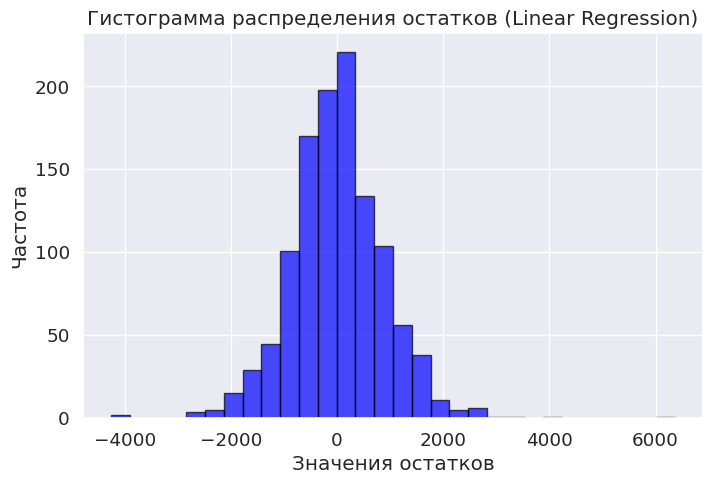

Статистика Колмогорова-Смирнова: 0.0445, P-значение: 2.0669e-02
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


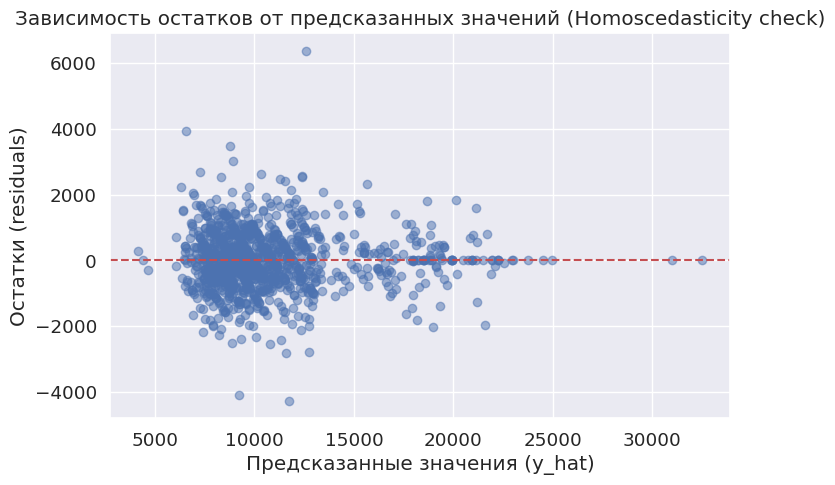

In [26]:
residuals = (y_train - y_pred_linear_train).ravel()
analyze_residuals(residuals, y_pred_linear_train)

In [27]:
ridge_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1)),
    ('model', Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0],
                    'poly__degree': [1,2]}

ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_e1, y_train)

print(ridge_grid.best_params_)

best_ridge=ridge_grid.best_estimator_

y_pred_ridge_train = best_ridge.predict(X_train_e1)
y_pred_ridge_test = best_ridge.predict(X_test_e1)

r2_score_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_score_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X=X_train_e1, y=y_train, cv=10).mean()

print("Ridge Regression Results:")
print("CV Mean: ", cv_ridge)
print(f"R2 Score (train): {r2_score_ridge_train:.4f}")
print(f"R2 Score (test): {r2_score_ridge_test:.4f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAPE: {mape_ridge:.4f}")

{'model__alpha': 100.0, 'poly__degree': 1}
Ridge Regression Results:
CV Mean:  0.8693100661533688
R2 Score (train): 0.9376
R2 Score (test): 0.9039
RMSE: 1132.42
MAPE: 0.0798


/tmp/ipykernel_17482/1322077046.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residuals_ridge = (y_train - y_pred_ridge_train).ravel()


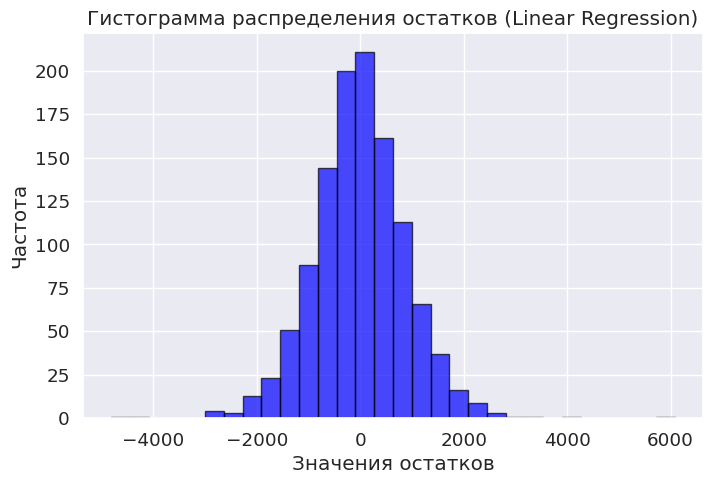

Статистика Колмогорова-Смирнова: 0.0365, P-значение: 9.1862e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


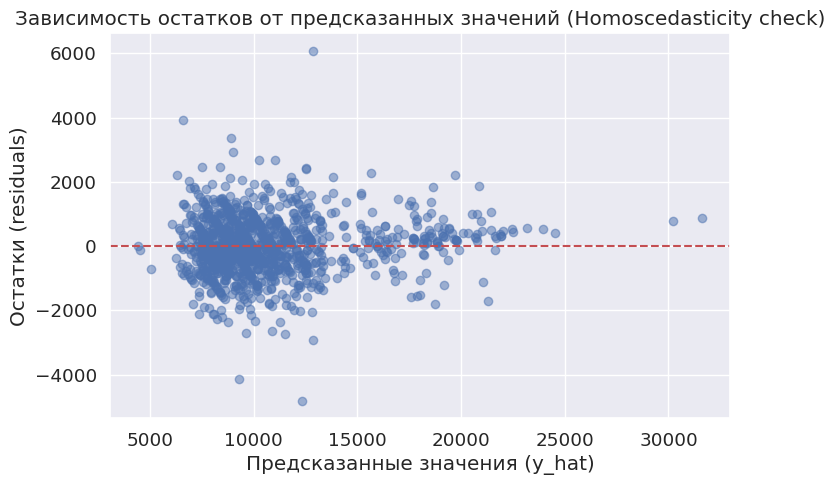

In [28]:
residuals_ridge = (y_train - y_pred_ridge_train).ravel()
analyze_residuals(residuals_ridge, y_pred_ridge_train)

In [32]:
lasso_steps = [
    ('scalar', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1)),
    ('model', Lasso(max_iter=10000))
]
# Долго просчитывается около 20 минут
lasso_pipe = Pipeline(lasso_steps)

lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
                    'poly__degree': [1,2] }

lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_e1, y_train)

best_par=lasso_grid.best_params_
print('Лучшие параметры для Lasso:',best_par)
best_lasso = lasso_grid.best_estimator_
print(f"Лучший параметр alpha для Lasso: {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train_e1)
y_pred_lasso_test = best_lasso.predict(X_test_e1)

r2_score_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_score_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train_e1, y=y_train, cv=10).mean()

print("Lasso Regression Results:")
print("CV mean :",cv_lasso)
print(f"R2 Score (train): {r2_score_lasso_train:.4f}")
print(f"R2 Score (test): {r2_score_lasso_test:.4f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAPE: {mape_lasso:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.955e+07, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.944e+07, tolerance: 1.145e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.882e+07, tolerance: 1.225e

Лучшие параметры для Lasso: {'model__alpha': 100.0, 'poly__degree': 1}
Лучший параметр alpha для Lasso: 100.0
Lasso Regression Results:
CV mean : 0.8830341127801805
R2 Score (train): 0.9054
R2 Score (test): 0.8920
RMSE: 1200.33
MAPE: 0.0863


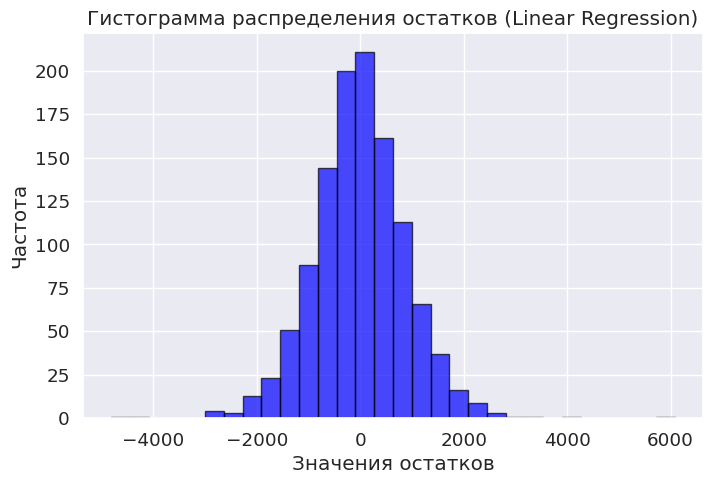

Статистика Колмогорова-Смирнова: 0.0365, P-значение: 9.1862e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


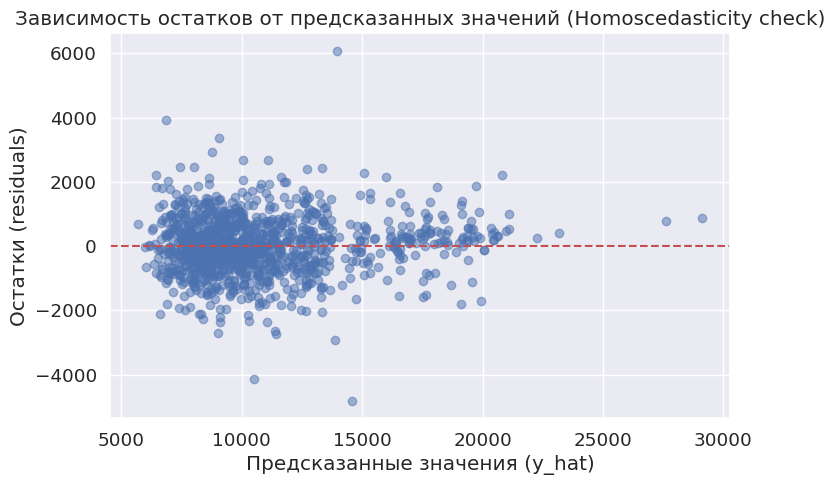

In [33]:
residuals_lasso = (y_train- y_pred_lasso_train)
analyze_residuals(residuals_ridge, y_pred_lasso_train)

## 3. Оценка качества и сравнение моделей

Сравните свои результаты с теми, которые вы получили от линейной регрессии.

**Ответьте на следующие вопросы: (если еще не отвечали в части про лин. рег)**
1. **Какие метрики вы использовали для сравнения моделей?** (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен $R^2$?).
2. **На какой части выборки вы считали метрики?**
3. **Какая модель по итогу справилась лучше?**
4. **Насколько хорошие получились результаты?**

In [34]:
res=[]

mae_lin=mean_absolute_error(y_test,y_pred_linear_test)
mae_rid=mean_absolute_error(y_test,y_pred_ridge_test)
mae_l=mean_absolute_error(y_test,y_pred_lasso_test)

mse_lin=mean_squared_error(y_test,y_pred_linear_test)
mse_rid=mean_squared_error(y_test,y_pred_ridge_test)
mse_l=mean_squared_error(y_test,y_pred_lasso_test)

res.append(['Linear Regression (Base)', rmse_linear,r2_score_linear_test,mae_lin,mse_lin])
res.append(['Ridge (GridSearchCV)', rmse_ridge,r2_score_ridge_test,mae_rid,mse_rid])
res.append(['Lasso (GridSearchCV)', rmse_lasso,r2_score_lasso_test,mae_l,mse_l])


rf_metrics = get_metrics(y_test,y_pred_rf)
tree_metrics=get_metrics(y_test,y_pred_tree)
res.append(['RandomForest', rf_metrics['RMSE'], rf_metrics['r2 '],rf_metrics['MAE'],rf_metrics['MSE']])
res.append(['DecisionTree', tree_metrics['RMSE'], tree_metrics['r2 '],tree_metrics['MAE'],tree_metrics['MSE']])


In [35]:
#байзлайны (моделька)
dumm_regr=DummyRegressor(strategy='mean')
dumm_regr.fit(X_train,y_train)

y_pred_bass=dumm_regr.predict(X_test)

bass_metrics=get_metrics(y_test,y_pred_bass)

res.append(['DummyRegressor',bass_metrics['RMSE'], bass_metrics['r2 '],bass_metrics['MAE'],bass_metrics['MSE']])

predict_df = pd.DataFrame(data=res, columns=['Model', 'RMSE', 'R2_Score(test)','MAE','MSE'])
display(predict_df.round(2))

,Model,RMSE,R2_Score(test),MAE,MSE
0,Linear Regression (Base),1131.96,0.90,792.06,1281324.36
1,Ridge (GridSearchCV),1132.42,0.90,788.25,1282385.44
2,Lasso (GridSearchCV),1200.33,0.89,846.44,1440787.49
3,RandomForest,973.14,0.93,744.34,947006.48
4,DecisionTree,1370.83,0.86,1024.80,1879165.52
5,DummyRegressor,3654.67,-0.00,2615.28,13356601.54


/tmp/ipykernel_17482/2973559345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
/tmp/ipykernel_17482/2973559345.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MSE', y='Model', data=predict_df.sort_values('MSE'), ax=axes[1], palette='mako')
/tmp/ipykernel_17482/2973559345.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MAE', y='Model', data=predict_df.sort_values('MAE'), ax=axes[2], palette='Blues')


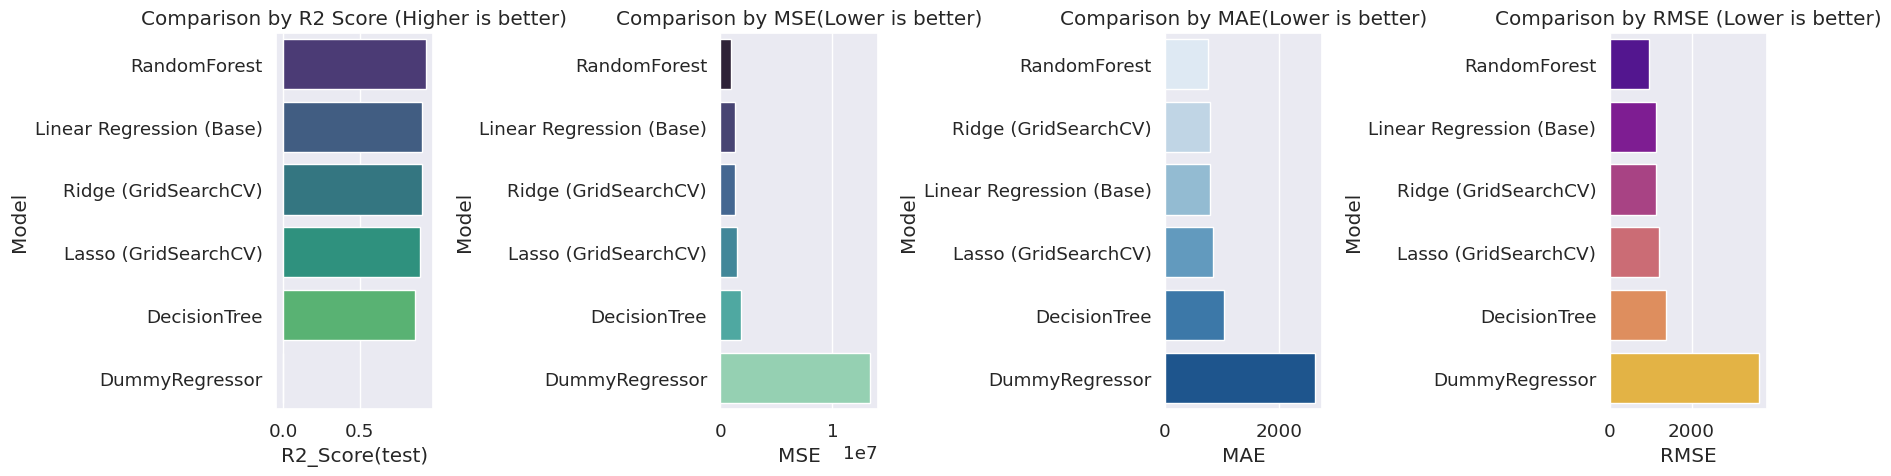

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MSE', y='Model', data=predict_df.sort_values('MSE'), ax=axes[1], palette='mako')
axes[1].set_title('Comparison by MSE(Lower is better)')

sns.barplot(x='MAE', y='Model', data=predict_df.sort_values('MAE'), ax=axes[2], palette='Blues')
axes[2].set_title('Comparison by MAE(Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[3], palette='plasma')
axes[3].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

**Ответьте на следующие вопросы: (если еще не отвечали в части про лин. рег)**
1. **Какие метрики вы использовали для сравнения моделей?** (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен $R^2$?).

Я использвала для анализа RMSE, R2,MSE. Выбрала RMSE так как она жестче наказывает модель за неверные предсказания и более чувствительна к выбросам. $R^2$ показывает какую долю дисперсии объясняет модель

2. **На какой части выборки вы считали метрики?**

Метрики по которым я оценивала модели считала на test, потому что модель не видела данные во время обучения.

3. **Какая модель по итогу справилась лучше?**

RandomForest. По всем метрикам модель справилось лучше и выдала довольно хорошие результаты выполнения.

4. **Насколько хорошие получились результаты?**

Результаты получились хорошие. Модели в процессе обучения не переобучились на train и test.
Модели хорошо объясняют дисперсию.

## Полезные функции и инструменты

Можно посмотреть документацию на:

**Предобработка и признаки**
* `sklearn.model_selection`: `train_test_split`
* `sklearn.preprocessing`: `StandardScaler`, `MinMaxScaler`, `OneHotEncoder`, `PolynomialFeatures`

**Модели**
* `sklearn.tree`: `DecisionTreeRegressor`
* `sklearn.ensemble `: `RandomForestRegressor`

**Метрики качества регрессии**
* `sklearn.metrics`: `mean_squared_error` (для MSE и RMSE), `mean_absolute_error` (MAE), `r2_score` ($R^2$)
* `sklearn.dummy`: `DummyRegressor` (для создания простого бейзлайна)